# QC V: Quantum Error Correction 

So far, we've been discussing a model of information and computation, where information is encoded into quantum states 
and computation is accomplished by manipulating these states. In the introduction, we also alluded to how at the high level, there is a way in which this is no different from regular computation. The "quantum" part comes from specifically using quantum states to do this over anything else. By encoding classical information into quantum states, we get access to a lot of interesting possible circuits that leverage the way quantum systems evolve and how they interact with each other. 





However, to consider information at a "resolution" as fine as this can be a double-edged sword. In the quantum description of reality, *anything* that affects physical or statistical signal at all must be accounted for in the formalism. Anything that you can physically interact with, can be considered together with a qubit as part of a joint system, and then any evolution of this joint system will affect the qubit (cosmic rays, sounds from the street, random magnetic fields...). This suggests that manipulating qubit states in isolation can be extremely difficult, or maybe even practically impossible!  From this point of view, it would seem that error correction is a central area of importance, if we are to actually implement quantum computers effectively in real life.





If we run some quantum algorithm to obtain some output state from which we want to extract some measurement statistics, we would want to at least know that we are measuring from the correct output and not some random output state. However, if the quantum circuit becomes coupled with the environment, the joint system may undergo some transformation that is out of our control. In such a scenario, the output state may be affected and become something else entirely. 

Let's model some noise and look at what can happen. 

In [58]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister,ClassicalRegister
import itertools
import numpy as np
from qiskit_aer import AerSimulator


def noise_model(a,b,circuit, print_option=False):
    
    ## A simple noise model.  
    # Introduce a random Pauli (X with “a” probability,Z with “b” probability) into any circuit.
    # Returns a quantum circuit which is the result of noise added to input circuit

    circuit_with_noise = circuit 
    qubits = circuit_with_noise.qubits 
    
    for qubit in qubits:
        
        error_choice = np.random.choice([0,1,2],p=[1 - (a+b), a,b])
        
        if error_choice == 1:
            circuit_with_noise.x(qubit)
            if print_option:
                print('X applied to ' + str(qubit) )
            
        elif error_choice == 2:
            circuit_with_noise.z(qubit)
            if print_option:
                print('Z applied to ' + str(qubit) )

    return circuit_with_noise 

In [59]:
from qiskit.quantum_info import Statevector

prep_circuit = QuantumCircuit(2) 

prep_circuit.h( prep_circuit.qubits )
statevector = Statevector(prep_circuit)
statevector.draw('Latex')



<IPython.core.display.Latex object>

In [95]:
prep_with_noise = noise_model(0.50,0.50, prep_circuit)
prep_with_noise.h(prep_with_noise.qubits)
statevector_noisy = Statevector(prep_with_noise)
statevector_noisy.draw('Latex')

<IPython.core.display.Latex object>

Since we inserted noise, applying $H^{\otimes n}$ to all of our qubits does not reverse the state preparation $\ket{00} \mapsto H^{\otimes 2}( \ket{00} )$ properly. We end up "decoding" our qubits back to $\ket{11}$ instead of $\ket{00}$. 

-------------------------

## How can we model noise in a quantum system? 

In order to handle errors and noise in a qubit system, we have to understand how we can model noise in a quantum system. What do we mean by error and noise? When we design a quantum circuit, we prepare some qubits and then place some gates on the circuit with the intention of affecting some particular change of the state of the system. Our circuits are modelled as closed quantum systems, where all of the change that happens to our system (except for measurements) are unitary transformations. So, when we talk about noise and error, we are essentially talking about transformations to the state of our circuit system, that are not accounted for by the unitary transformations defined to be on the circuit itself. 



Recall that while unitary transformations model state evolution for closed systems, we often have to talk about non-unitary processes to a system that may occur ( for example, when when taking a measurement). I briefly mentioned that there is another formulation of the postulates of quantum mechanics that directly addresses the fact that there may be a larger "environment system" beyond a system of interest. Through the larger system, we may be able to understand a non-unitary transformation of system as a unitary transformation, but it may not appear to be unitary if we are only able to interact with the smaller subsystem. 




In describing this idea, John Smolin coined a humorous saying: ["Going to the Church of the Larger Hilbert Space"](https://www.quantiki.org/wiki/church-larger-hilbert-space). As funny as that saying may be, this is actually mathematically supported by the "Stinespring Dilation theorem" -- it roughly says that we can always tensor a system together with another Hilbert space to create a larger Hilbert space, from which we can view some non-unitary transformation as arising from a unitary transformation on this larger space. We haven't really said enough about the formalism being the kinds of permissible non-unitary transformations we should account for, and how we can view unitary transformations of the environment from the point of view of the "closed-off system" (where it appears non-unitary), for this to be stated properly.. but hopefully you can get the idea. 






However, we can illustrate the idea with an example. Suppose that we have a $2$-qubit system $\mathcal{H}(2)$, where we only have access to one of the qubits. Let's label these as $\ket{q_{e}}$ for the environment qubit, and $\ket{q}$ for the qubit we have access to. We can imagine that a quantum circuit with two wires represents a larger environment, while our simple quantum computer consists of just a single wire where the qubit $\ket{q}$ lives. While the wire with the qubit $\ket{q_e}$ has been hidden from us so that we cannot interact with it (i.e. place gates on the wire or take any measurements), $\ket{q_e}$ can still interact with $\ket{q}$. 

Suppose that the two qubits happen to go through a $CX$ gate together. We can represent the joint $CX$ gate as the following unitary transformation:

$$
CX = \ket{0}  \bra{0} \otimes \mathbb{I} + \ket{1} \bra{1}  \otimes X = \begin{pmatrix} 1 & 0  \\ 0 & X \end{pmatrix}
$$






If the environment qubit $\ket{q_{e}}$ happens to be in the $\ket{0}$ state, then this $CX$ gate will appear to our view as an identity map. If the environment qubit happens to be in the $\ket{1}$ state, then the $CX$ gate will appear to our view as an $X$-gate. 
However, if $\ket{q_{e}}$ is in superposition, the induced $CX$ action to our view no longer appears to be unitary! 

Indeed, if $\ket{q_{e}} = \alpha \ket{0} + \beta \ket{1}$, then

$$
CX( \ket{q_{e}} \ket{q} ) = ( \alpha \ket{0} \otimes \mathbb{I} \ket{q}  + \beta \ket{1} \otimes  X \ket{q}  ) = \alpha \ket{0} \otimes \ket{q}  + \beta \ket{1} \otimes  X \ket{q} 
$$





Without knowledge of the state of the external qubit $\ket{q_{e}}$, we do not have any idea what the $CX$ transformation has done to our qubit $\ket{q}$. From our point of view, we do not have a deterministic state of our qubit $\ket{q}$ -- what we have instead is some kind of probability distribution over the possible states our internal system could be in (one says that our internal system is in a *mixed state*). What we have now , from the internal system's perspective, is not modelled by just a state vector. This is where the language of open quantum systems is more flexible: these mixed states can be viewed as density operators. Density operators give us a way to extend our notion of statevectors (pure states) and talk about probability distributions of possible states (mixed states). We can still talk about this from the point of view of closed systems. When we ignore the external qubit, we can safely think of the process as though the external qubit has been “measured out.” That is, the external qubit may be projected onto one of its possible basis states, and the internal qubit is then left in the corresponding conditional state. Since we do not have access to the external qubit or to any record of which outcome occurred, we average over all of these possible outcomes. From the perspective of the internal system alone, this is indistinguishable from an actual measurement of the external qubit whose result was never communicated. In this sense, tracing out the external qubit lets us replace the original joint state with a probabilistic description of the internal qubit alone. With that in mind, we can think of the joint $CX$ action, from the perspective of the internal qubit as having a probabilistic outcome. With probability $| \alpha |^{2}$ , nothing has happened to $\ket{q}$ ;  and with probability $\beta|^{2}$, $\ket{q}$ has gone through an $X$-gate. 




So, to address how we should model noise and errors to an internal system with the (very real) possibility that there is an external environment outside of our circuit (duh?), we can think about how if we extended our realm of consideration enough, any evolution of the encompassing system will be unitary. From the point of view of our internal system, we will at least see that the error can be modelled by saying that with some probability, a linear operator $E: \mathcal{H} \rightarrow \mathcal{H}$ (which is not necessarily unitary, or even observable!) has been applied to our system. If we consider single qubit errors, we can say something much more:  an important property of the Pauli matrices $I,X,Y,Z$ is that they span the space of linear operators for a single qubit system $\mathcal{H}(1)$, which means that any error on a single qubit can be modelled as a linear combination of Pauli matrices $E = a_{0} I + a_{X} X + a_{Y} Y + a_{Z} Z$. So, at least for single qubit systems, we can convince ourselves that if we can address any *Pauli error* well, then we should be able to handle any type of error. When a system undergoes noise or error, we can model this by saying that with some probability, some linear combination of Pauli matrices has been applied to our system. 

However, it is convenient to simplify our error model and consider random single Pauli errors. This is when we reduce our error model to only consist of one Pauli matrix at a time. That is to say, with the Pauli error model, when a system undergoes an error, a Pauli operator has been applied to the system at random. Of course, it is better to be able to handle *any* type of error well, but we will be able to get a much better handle on Pauli errors. As long as we are upfront and honest about the type of errors we will be dealing with, any headway in the business of error correction will be valuable.





<!-- As we do not have any access to the external environment, and we are discarding any record of $\ket{q_{e}}$ by replacing the state of the internal system with a probabilistic mixed state, there is no way to detect any further evolution of the external system that $\ket{q_{e}}$ lives on from the perspective of the internal system. This means that if something or someone took a measurement of the qubit $\ket{q_{e}}$, the internal qubit $\ket{q}$ would not know the difference.   -->


-------------------------

## How is quantum error correction different from classical error correction?

From a practical point of view*, both quantum and classical error correction can be considered to have a similar goal. If we view a circuit as a certain mapping from an input state to an output state, we want to be able to maintain the desired output state even in the presence of noise. However, things are more intricate in the quantum setting. Of course, in the quantum setting we cannot just look at our qubits to see if an error has occured -- because in doing that, we would risk disrupting our quantum system... which would potentially cause even more issues than the errors we are trying to correct ever did! 

<span style="color:lightgreen"> <small> (small unimportant comment: there is also an "impractical" way to think about quantum error correction... One could say that we are just trying to understand how quantum information can "scale" from smaller quantum systems to larger quantum systems. This is a matter of understanding the nature of quantum information itself, as opposed to clever engineering)</small> </span>



#### Syndrome measurement 

As the goal of a quantum error correction code is to maintain a specific quantum state, one needs to understand how to operate on a given qubit system appropriately after it has gone through possible noise, without collapsing the state of the system. In particular, we cannot simply measure the state of the qubit system and operate according to the result of the measurement. Instead, the qubit system is coupled with another auxillary system of qubits, referred to as *syndrome qubits*. One can measure the syndrome qubits without collapsing the state of our original qubit system (the qubits in the original qubit system are sometimes referred to as *data qubits*). If this is done appropriately, in principle we can measure the state of the syndrome qubit system and then operate on the data qubit system accordingly. 

Of course, in the process of coupling the data qubit system with the syndrome qubit system, measuring the syndrome qubits may also have an effect on our data qubit system. Therefore, care must be taken in designing a quantum error correcting code, so that measuring the syndrome qubit system does not result in potential undesired effects on the data qubits. 

Furthermore, by the *no-cloning theorem*, the syndrome qubit system cannot simply be a perfect replica of the data qubit system. Therefore, the best that one can hope for in general, is that measuring the syndrome system will "inform us", or provide some *hint* about the state of the data qubits; and in hopes of maintaining a desired output state, one can operate on the data qubit system according to syndrome measurements in an appropriate way. 



--------------------
## Some initial examples 



### The repetition code

Let's look at some basic error correcing schemes. As in the classical setting, we can start by looking at the most obvious thing: the repetition code. Instead of using $1$-qubit whose computational basis states can be used encode single classical bits, we can use $n$-qubits. Then $\ket{0}$ will be replaced with $\ket{0}_{L} = \ket{00 \cdots0}$ and $\ket{1}$ will be replaced with $\ket{1}_{L} := \ket{11 \cdots 1}$. The subscript $L$ stands for "logical", meaning that we are treating the multiqubit states $\ket{00 \cdots 0}$ and $\ket{11\cdots 1}$ as "logically" representing $0$ and $1$. 






Let's consider what happens when the $n$-qubit system, representing a repetition code encoded $1$ logical qubit system under goes an $X$ error (bit flip error). 
In this model, we will assume that each qubit can independently undergo a random Pauli $X$ operation with probability $p$. Then, the probability that $k \leq n$ errors have occured is given by 

$$
\binom{n}{k} p^{k}(1-p)^{n-k}
$$

Let's consider this when $n = 3$. So, 

|  # of errors  | Probability of happening  |   
|---------------|---------------------------|
|   $0$         |   $(1-p)^{3}$             |
|   $1$         |   $3 p(1-p)^{2}$          |
|   $2$         |   $3 p^{2} (1-p)$         |
|   $3$         |       $p^{3}$             |   

How do we detect and correct errors? As mentioned before, we need to use syndrome qubits. For the $3$-qubit repetition code, we will use $2$ syndrome qubits. Basically the error correction scheme can be summed up in this graph:

<img src="syndromediagram1.jpg" style="display: block; margin: auto; width: 75%">


In the diagram above, the syndrome qubits are labelled $s_{0}$ and $s_{1}$, while the *data qubits* are labelled $q_{0}, q_{1}, q_{2}$. Each syndrome qubit $s_{i}$ is coupled with the data qubits connected to $s_{i}$ by an edge in the above graph, and passed through some controlled gates. These controlled gates will target the syndrome qubit, and be controlled by the data qubits. In this way, the syndrome qubit will be in a state that has a "hint" about what the states of the neighbouring data qubits. 

Let's look at this in code.

In [96]:
data_qubits = QuantumRegister(3, "q")
syndrome_qubits = QuantumRegister(2, "s")
rep_code = QuantumCircuit( data_qubits, syndrome_qubits  )

# rep_code.cx( 0 , 1 )
# rep_code.cx( 0 , 2 )


for idx,qubit in enumerate(syndrome_qubits):
    rep_code.cx( qubit, data_qubits[idx] )
    rep_code.cx( qubit, data_qubits[idx+1])


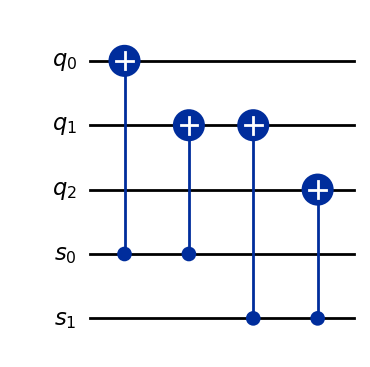

In [97]:
rep_code.draw('mpl')

Let's look at what happens to the syndrome qubits $s_{0}, s_{1}$ if a single Pauli $X$ is applied to one of the data qubits $q_{0}, q_{1}, q_{2}$, but let's say that we don't know which of the $3$ qubits it has been applied to. 
We initialize the syndrome qubits to be in the state $\ket{00}$. 

|   $X$ Error location | Syndrome state $\ket{s_{1} s_{0}}$          |
|----------------------|---------------------------------------------|
|    $q_{0}$           |       $\ket{01}$                            |
|    $q_{1}$           |       $\ket{11}$                            |
|    $q_{2}$           |       $\ket{10}$                            |


It is important to note that when we do the controlled $X$ gates, they target the syndrome qubits and it does not touch the data qubits at all. 
So, we can actually extract the index of the $X$ error location on the $3$ data qubits by measuring the syndrome qubits. This will leave the data qubits untouched, as the syndrome qubits and data qubits are not entangled, and the controlled $X$ gates never affected the state of the data qubits. 


Let's insert some noise after the repetition code state preparation (which wasn't much) and see how we can preserve the initial state $\ket{00}$ via syndrome measurements. 

In [101]:
syndrome_measurement = ClassicalRegister(2)

rep_code_with_noise = QuantumCircuit( data_qubits, syndrome_qubits, syndrome_measurement  )


rep_code_with_noise.x(data_qubits[0]) 


for idx,qubit in enumerate(syndrome_qubits):
    rep_code_with_noise.cx(  data_qubits[idx] , qubit)
    rep_code_with_noise.cx( data_qubits[idx+1], qubit)
    
rep_code_with_noise.measure(syndrome_qubits, syndrome_measurement)


result = AerSimulator().run(rep_code_with_noise, shots=1, memory=True).result().get_memory(rep_code_with_noise)  

print(result)




['01']


Indeed, this syndrome measurement corresponds to us putting an $X$ gate on the qubit $q_{1}$. 

Since we know where the $X$ error occured, we can undo the $X$ error by just applying $X$ to $q_{1}$ (as $X^{2} = I$)

In [102]:
rep_code_with_noise.x( data_qubits[0]  )

> <b> Question:</b> what is the state of the data qubits now? What about the syndrome qubits? 
> What if we run the part run the "syndrome checking"  part of the circuit again, and measure? What will the result be?

In [65]:

for idx,qubit in enumerate(syndrome_qubits):
    rep_code_with_noise.cx(  data_qubits[idx] , qubit)
    rep_code_with_noise.cx( data_qubits[idx+1], qubit)
    
rep_code_with_noise.measure(syndrome_qubits, syndrome_measurement)

In [66]:
result = AerSimulator().run(rep_code_with_noise, shots=1, memory=True).result().get_memory(rep_code_with_noise)  

print(result)

['11']


Note that the data qubits were reset back to $\ket{00}$ after reading the syndrome "hint" for where the $X$ error occured, the syndrome qubits were never reset -- so they stay in the measurement projection state of $\ket{11}$. The controlled $X$ gates didn't do anything, as the data qubits are in state $\ket{00}$. 

Moral: make sure you either use fresh syndrome qubits, or reset them! But.. if you try reset them, note that the information of the state has to go somewhere... 

> <b> Question:</b > Think about the information that we are encoding onto the syndrome qubits, and what are reading off of them. 
>  1. Do you think it's possible to reliably correct more than $1$ $X$-error? 
>  2. Can we correct more than one type of error? Maybe $X$ and/or $Z$ error?  
>  3. Would it help to do a repetition code with more qubits? (larger $n$)
> 

We can modify our repetition code to handle $Z$ errors instead of $X$ errors. This relies on the fact that the Hadamard gate interchanges the $X$ and $Z$ operators. That is,
$HXH = Z$, or $HZH = X$. So, if we can manage to prepare the state of $H^{\otimes 3} \ket{000}$ before the error occurs, then we can convert our repetition code circuit to one that detects phase flip errors ($Z$ errors).

In [67]:
data_qubits = QuantumRegister(3, "q")
syndrome_qubits = QuantumRegister(2, "s")
syndrome_measurement  = ClassicalRegister(2) 
rep_code_phase = QuantumCircuit( data_qubits, syndrome_qubits,syndrome_measurement   )

rep_code_phase.cx( 0 , 1 )
rep_code_phase.cx( 0 , 2 )
rep_code_phase.h( data_qubits )


## some Z error may happen here
rep_code_phase.z( np.random.choice([0,1,2])) 



## syndrome measurement 
rep_code_phase.h( data_qubits )
for idx,qubit in enumerate(syndrome_qubits):
    rep_code_phase.cx( data_qubits[idx] , qubit)
    rep_code_phase.cx( data_qubits[idx+1], qubit)
    
rep_code_phase.measure(syndrome_qubits, syndrome_measurement)

In [68]:
result = AerSimulator().run(rep_code_phase, shots=1, memory=True).result().get_memory(rep_code_phase)  

print(result)

['01']


### The $9$-qubit Shor code


We can concatenate the two codes above (the $3$-qubit repetition code for a single $X$-error and the modification that corrects for a single $Z$-error). We think of the $3$-qubit repetition code as encoding the logical state of a single qubit into three qubits. When we do this, we can decide if we want the design our repetition code in a way to handle single $X$-errors, or to handle $Z$-errors. We can use encode the logical state of a single qubit into nine qubits by iterating this construction twice, and then choosing the two iterations to be of $X$ and $Z$ types respectively. 

That is, we will have two encoding layers: first, we can encode our single qubit into three qubits, and then we can repeat the procedure for each of the qubits in the three. In the end, we will have $9$ qubits and $2$ encoding layers. The outer (first) layer can be used for correcting single $Z$-errors, and the inner (second) layer can be used for correcintg single $X$-errors. 

Here is what the circuit diagram looks like when we put it all together. For visual convenience, I put a grey dividing line to delineate the two layers of repetition codes.. there isn't really a physical barrier there or anything like that.

<img src="shordiagram.jpg" style="display: block; margin: auto; width: 75%">



From our prior discussion of the repetition code, we can introduce syndrome qubits and detect a single $X$-error on any of the qubits. 

For a total of $8$ syndrome qubits, we can also use syndrome qubits to detect single phase flip errors that occur within each of the three blocks. Note that a phase flip error located on the inner layers will be ultimately detected by a syndrome qubit for the corresponding outer layer. In light of this, it is also true that the outer layer syndrome qubits cannot specify the location of the phase error within an single inner layer itself, but can only detect the inner layer from which the $Z$-error has occured. Fortunately, by the nature of phase corrections, we can apply a $Z$-gate to any of the three qubits contained in a single inner block to correct the reported $Z$-error.  

We can diagramically represent the syndrome and data qubit arrangements with a graph as depicted below. The green squares represent "checks" for detecting $X$-errors, and the red squares represent checks for detecting $Z$-errors.  

<img src="syndromediagram2.jpg" style="display: block; margin: auto; width: 50%">


In [69]:
def shor_code(state=0):
    #Returns a circuit that initializes Shor's 9 qubit code.
    
    # Optional parameter 'state' is set to 0 by default. If state == 1, then 
    # Shor's code will be initialized to logical state 1 
    
    shor_circuit = QuantumCircuit(9)
    
    shor_circuit.cx(0,3)
    shor_circuit.cx(0,6) 
    
    for idx in range(len(shor_circuit.qubits)):
        if idx%3 == 0:
            lead_qubit = shor_circuit.qubits[idx]
            shor_circuit.h( lead_qubit )
            shor_circuit.cx(lead_qubit, shor_circuit.qubits[idx+1])
            shor_circuit.cx(lead_qubit,  shor_circuit.qubits[idx+2])
            
    if state == 1:
        for qubit in shor_circuit.qubits:
            shor_circuit.x(qubit) 

    return shor_circuit


shor_code_ = shor_code() 
statevector = Statevector(shor_code_)
statevector.draw('Latex')

<IPython.core.display.Latex object>

In [70]:
shor_code_with_noise = noise_model(0.05, 0.05, shor_code_, print_option=True)

In [71]:
            
def syndrome_measure(code_circuit, table, pauli_type):
    
    code_ancillas = AncillaRegister(len(table))
    code_classical_bits = ClassicalRegister(len(table))
    
    code_circuit.add_register(code_ancillas)
    code_circuit.add_register(code_classical_bits)
    
    for key in table:
        code_circuit.h(code_ancillas[key])
        for idx in table[key]:
            if pauli_type == 'X':
                code_circuit.cx(code_ancillas[key], code_circuit.qubits[idx])
            elif pauli_type == 'Z':
                code_circuit.cz( code_ancillas[key], code_circuit.qubits[idx])
                
        code_circuit.h(code_ancillas[key])
        code_circuit.measure(code_ancillas[key], code_classical_bits[key])

def measure_data( code_circuit, qubits ):
    classical_reg = ClassicalRegister(len(qubits))
    code_circuit.add_register(classical_reg)
    
    for idx in range(len(qubits)):
        code_circuit.measure(qubits[idx], classical_reg[idx])
        
    job = AerSimulator().run(code_circuit, shots=1, memory=True)   
    result = job.result()
    memory = result.get_memory(code_circuit)
    return memory[0][:len(qubits)]

In [72]:
Z_shor_syndrome_table = {0: [0,1,2,3,4,5] , 1: [3,4,5,6,7,8]}
# Shor's code consists of 2 syndrome ancillas, 
# overlapping in a single block/"plaquette" consisting of 3 qubits

# syndrome outcomes, assuming a single error:
# (0,0) : even parity for all blocks
# (1,0) : odd parity in first block 
# (0,1) : odd parity in third block
# (1,1) : odd parity in second block
Z_shor_decode_table = { '00': -1,  '10' : 0, '01': 6, '11': 3}

In [73]:
syndrome_measure( shor_code_with_noise ,   Z_shor_syndrome_table, 'X')

job = AerSimulator().run(shor_code_with_noise, shots=1, memory=True)   
result = job.result()
memory = result.get_memory(shor_code_with_noise)
target_qubit = Z_shor_decode_table[memory[0][::-1]]
# print( memory[0][::-1] )
# print(target_qubit)
if target_qubit != -1:
    shor_code_with_noise.z(shor_code_with_noise.qubits[target_qubit])

In [74]:
X_shor_syndrome_table = {0: [0,1] , 1: [1,2], 2: [3,4], 3: [4,5], 4:[6,7], 5:[7,8]}
X_shor_decode_table = {'000000': -1, '100000': 0, '110000':1, '010000': 2, '001000': 3, '001100':4, '000100':5, '000010': 6, '000011': 7, '000001': 8}
syndrome_measure( shor_code_with_noise ,  X_shor_syndrome_table, 'Z')
job = AerSimulator().run(shor_code_with_noise, shots=1, memory=True)   
result = job.result()
memory = result.get_memory(shor_code_with_noise)[0][::-1].replace(' ', '')[2:]
target_qubit = X_shor_decode_table[memory]
# print(memory)
# print(target_qubit)
if target_qubit != -1:
    shor_code_with_noise.x(target_qubit)
    

In [75]:
shor_code_with_noise.compose(shor_code().inverse(), inplace=True )

result  = measure_data(shor_code_with_noise, [shor_code_with_noise.qubits[idx] for idx in range(9)] )
print(result)   

000000000


## Stabilizer formalism

How can we design more codes? Do we just have to rely on being clever? Fortunately, there is a general family of quantum error correcting codes called *stabilizer codes* for which there exists a rich formalism for how to think about quantum error correcting codes and how we can design new codes. 

<!-- To motivate the definition of a stabilizer code, let's look at the following illustrations: -->


<!-- <img src="error1.jpg" style="display: block; margin: auto; width: 50%"> -->




Every Pauli error on an $n$-qubit system can be written as a tensor $\sigma_{0} \otimes \sigma_{1} \otimes \cdots \sigma_{n-1}$  where $\sigma_{i}$ is either $I, X, Y $ or $Z$. We call operators of this form *Pauli strings*, and it's often convenient to write them like $X_{0}Z_{1}X_{3}$ to indicate the Pauli string $X_{0} \otimes Z_{1} \otimes X_{3}$, for example. These Pauli strings generate the group of Pauli operators $\mathcal{P}_n$ on $\mathcal{H}(n)$. Furthermore, Pauli strings will either always commute or anticommute with each other. The *weight* $w(\sigma)$ of a Pauli string $\sigma$ is the number of non-identity factors in the Pauli string of $\sigma$ 



A stabilizer group $\mathcal{S} \leq \mathcal{P}_{n}$ is a subgroup of Pauli operators generated by Pauli strings of the form $\sigma = \sigma_{0} \otimes \sigma_{1} \otimes \cdots \otimes \sigma_{n-1}$ where each $\sigma_{a}$ is either $I, X$ or $Z$, and $[\sigma,\sigma'] = 0$ for any two $\sigma, \sigma' \in \mathcal{S}$. We also want that there exists at least one quantum state vector to be fixed by the collection of all the generators of $\mathcal{S}$. Essentially, the stabilizer generators $\sigma \in \mathcal{S}$ will end up forming a collection of observables that we will be able to use to detect if an error has occured in our system. The commutation property $[\sigma,\sigma'] = 0$ demands that these the measurement of these observables do not interfere with each other (they are simutaneously diagonalizable).  The condition tells us that we will have at least one non-trivial eigenvector. 




The point here is that when we do error correction, we would like to encode our logical information into a subspace $\mathcal{C}$ of $\mathcal{H}$, where the subspace $\mathcal{C}$ is more robust to certain error operations. Given a stabilizer group $\mathcal{S}$, we can take $\mathcal{C}$ to be the fixed subspace $\text{Fix}(\mathcal{S}) \subset \mathcal{H}$. That is, each element of $\mathcal{S}$ fixes $\mathcal{C}$ pointwise so that $\mathcal{C}$ consists of simutaneous $+1$ eigenvectors of all the Pauli string generators of $\mathcal{S}$.  We say that this subspace $\mathcal{C}$ forms the *code states* of our code.


If an error $E$ is applied to the system, then either

1. $\pm E \in \mathcal{S}$, so that  can be generated by the Pauli strings that generate $\mathcal{S}$. If that is the case, then $\pm E$ will preserve all the code states, and thus our logical qubits. This encoding is totally robust to this type of error, it will have no effect on space of logical qubits. 

2. $\pm E$ anti-commutes with at least one of the stabilizer generators. In This situation, $E$ will turn our code states into $-1$ eigenvector of the corresponding stabilizer generator. These are the types of error that we will be able to detect and correct.

3. $\pm E$ commutes with all stabilizer generators, but is not in $\mathcal{S}$. In this case, $\mathcal{S} \big( E \ket{q}_{L} \big) = E \mathcal{S} \big( \ket{q}_{L} \big) = E \ket{q}_{L}$, so that $E \ket{q}_{L}$ is a $+1$ eigenvector of $\mathcal{S}$. This means that this type of error will go undetected by the stabilizer generators. 


So, it sounds like we want to be measuring eigenvectors/eigenvalues of the stabilizer generators in order to detect errors. So, for each stabilizer generator, we will be introducing a syndrome qubit. This will be used to record the eigenvalue reading of a stabilizer check, in order to determine if an error has happened. 

A quantum error correcting code has a "signature" given by  $[[n,k,d]]$. Here, $n$ is the number of physical qubits, $k$ is the number of logical qubits you can encode with the code, and $d$ stands for *code distance*. The code distance is related to the number of errors your code can reliably correct. It is given by $\min \{ w(\sigma) \mid \sigma \in N(\mathcal{S}) \setminus \mathcal{S} \}$, so it is the smallest Pauli error (in weight) that is undetectable by our code, and is not a stabilizer of the code. We can reliably correct up to $\lfloor \frac{d -1 } {2} \rfloor$ many errors in our code.

For example, the $9$ qubit Shor code has signature $[[ 9, 1, 3 ]]$. 

###  CSS codes

There are some nice simplifications of the above stabilizer formalism that allows us to think about these codes in a more combinatorial way. 
First of all, a CSS (Calderbank-Steane-Shor) code is a simplification of a stabilizer code, where the stabilizer generators can all be written as Pauli strings with either only $X$ operators involves or only $Z$ operators involved. This simplifies the description of the code greatly, as for example we know exactly what types of Pauli errors anticommute with the stabilizer generators. 


<img src="stabilizercheck.jpg" style="display: block; margin: auto; width: 50%">


In the diagram above, we have that the Pauli string $X_{i_{1} i_{2} \cdots i_{4}} = X_{i_{1}}X_{i_{2}} X_{i_{3}} X_{i_{4}}$ is a stabilizer generator of our CSS code. The qubits $\ket{q_{i_1} q_{i_2} q_{i_3} q_{i_4} }$ are in a state that is fixed by $X_{i_{1} i_{2} \cdots i_{4}}$. If a single $Z$ error occurs among the qubits $\ket{q_{i_j}}$, then a syndrome qubit will be able to detect that $Z \ket{q_{i_1} q_{i_2} q_{i_3} q_{i_4} }$  is in a $-1$ eigenstate of $X_{i_{1} i_{2} \cdots i_{4}}$, so that a $Z$ error has occured somewhere in the support of this stabilizer generator. 

Looking back at the graphs from before, we see that these are all examples of CSS codes. In fact, they are CSS codes where all the stabilizer weights are *even*. These graphs are called Tanner graphs. 

I can specify a stabilizer code from a Tanner graph by taking all the "X-type checks", and adding as a generator $X_{i_{1}} X_{i_{2}} \cdots X_{i_{m}}$ for indices $i_{1}, \cdots i_{m}$ in the support of the $X$-check, and vice versa for the Z-type checks. 

For example, the $9$ qubit Shor code can be described as the stabilizer code 

$$
\begin{pmatrix}
X_{0} & X_{1} & I & I & I& I & I & I & I  \\ 
I & X_{1} & X_{2} & I & I& I & I & I & I  \\
I & I  & X_{2} & X_{3} & I& I & I & I & I  \\
I & I & I & X_{3} & X_{4} & I & I & I & I \\
I  & I & I & I & X_{4}& X_{5} & I & I & I  \\
I  & I & I & I & I & X_{5} & X_{6} & I & I \\
Z_{0} & Z_{1} & Z_{2} & Z_{3} &  Z_{4} & Z_{5} & I & I & I \\
I & I & I & Z_{3}  &  Z_{4} & Z_{5} & Z_{6}   & Z_{7} & Z_{8}  \\
\end{pmatrix}
$$

Here's another possible Tanner graph (we haven't depicted the check nodes):

<img src="steane.jpg" style="display: block; margin: auto; width: 50%">



Each face has $4$ qubits that make up the support of either a $X$ or $Z$ type generator (this will be a CSS code). Given the qubit ordering above, can we write down the stabilizer generators? 

This is called the Steane code. 

In [76]:
def steane_code(state=0):
    # Returns a circuit that initializes Steane's code 
    # (i.e. the quantum CSS code defined by using Hamming code matrices as the parity check matrices ).
    
    # Optional parameter 'state' is set to 0 by default. If state == 1, then 
    # Steane's code will be initialized to logical state 1     
    
    
    steane_circuit = QuantumCircuit(7)
    steane_leaders = [0,1,3]
    for idx in steane_leaders:
        steane_circuit.h(  steane_circuit.qubits[idx] )
        if idx == 0:
            steane_circuit.cx(steane_circuit.qubits[0], steane_circuit.qubits[2] )
            steane_circuit.cx(steane_circuit.qubits[0], steane_circuit.qubits[4] )
            steane_circuit.cx(steane_circuit.qubits[0], steane_circuit.qubits[6] )
        elif idx == 1:
            steane_circuit.cx(steane_circuit.qubits[1], steane_circuit.qubits[2] )
            steane_circuit.cx(steane_circuit.qubits[1], steane_circuit.qubits[5] )
            steane_circuit.cx(steane_circuit.qubits[1], steane_circuit.qubits[6] )
        elif idx == 3:
            steane_circuit.cx(steane_circuit.qubits[3], steane_circuit.qubits[4] )
            steane_circuit.cx(steane_circuit.qubits[3], steane_circuit.qubits[5] )
            steane_circuit.cx(steane_circuit.qubits[3], steane_circuit.qubits[6] )
            
    if state == 1:
        for qubit in steane_circuit.qubits:
            steane_circuit.x(qubit)
            
    return steane_circuit 

In [77]:
steane_code_ = steane_code()

In [78]:
statevector = Statevector(steane_code_)
statevector.draw('Latex')

<IPython.core.display.Latex object>

In [79]:
steane_code_with_noise = noise_model( 0.05,0.05, steane_code_ , print_option=True )

X applied to <Qubit register=(7, "q"), index=4>


In [80]:
steane_syndrome_table = { 0 : [0,2,4,6], 1: [1,2,5,6] , 2: [3,4,5,6] }
steane_decoding_table = { '001': 0, '010': 1, '100': 3, '011' : 2, '101': 4, '110': 5, '111': 6 }

In [81]:
syndrome_measure( steane_code_with_noise ,   steane_syndrome_table, 'X')

job = AerSimulator().run(steane_code_with_noise, shots=1, memory=True)   
result = job.result()
memory = result.get_memory(steane_code_with_noise)
target_idx = int(memory[0][-3:],2)-1
if target_idx != -1:
    steane_code_with_noise.z( target_idx )

In [82]:
syndrome_measure( steane_code_with_noise ,   steane_syndrome_table, 'Z')
job = AerSimulator().run(steane_code_with_noise, shots=1, memory=True)   
result = job.result()
memory = result.get_memory(steane_code_with_noise)
target_idx = int(memory[0][:3],2) - 1
if target_idx != -1:
    steane_code_with_noise.x( target_idx )

In [83]:
steane_code_with_noise.compose(steane_code().inverse(), inplace=True )

result  = measure_data(steane_code_with_noise, [steane_code_with_noise.qubits[idx] for idx in range(7)] )
print(result) 

0000000
